In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             PrecisionRecallDisplay, RocCurveDisplay)
from yellowbrick.classifier import ClassPredictionError

In [16]:
df = pd.read_csv("/Users/wangjingwen/Documents/GitHub/is6400-business-data-analytics/data/cleaned_loan_data.csv")
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3,640,No,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42776 entries, 0 to 42775
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42776 non-null  int64  
 1   person_gender                   42776 non-null  object 
 2   person_education                42776 non-null  object 
 3   person_income                   42776 non-null  float64
 4   person_emp_exp                  42776 non-null  int64  
 5   person_home_ownership           42776 non-null  object 
 6   loan_amnt                       42776 non-null  float64
 7   loan_intent                     42776 non-null  object 
 8   loan_int_rate                   42776 non-null  float64
 9   loan_percent_income             42776 non-null  float64
 10  cb_person_cred_hist_length      42776 non-null  int64  
 11  credit_score                    42776 non-null  int64  
 12  previous_loan_defaults_on_file  

In [18]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000
mean,27.609056,70852.732443,5.262741,9275.487586,10.993112,0.143362,5.780251,632.323523,0.229100
std,5.830140,32447.846522,5.840831,6041.753786,2.975452,0.087443,3.825896,50.403992,0.420259
min,20.000000,8000.000000,0.000000,500.000000,5.420000,0.010000,2.000000,390.000000,0.000000
25%,24.000000,46149.000000,1.000000,5000.000000,8.590000,0.080000,3.000000,601.000000,0.000000
50%,26.000000,65645.500000,4.000000,8000.000000,11.010000,0.130000,4.000000,639.000000,0.000000
75%,30.000000,90756.250000,8.000000,12000.000000,12.990000,0.190000,8.000000,669.000000,0.000000
max,78.000000,168633.000000,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [19]:
loan_status = df['loan_status'].value_counts(dropna=False)
loan_status

loan_status
0    32976
1     9800
Name: count, dtype: int64

In [20]:
# 类别变量编码
df['person_gender'] = df['person_gender'].map({'male': 0, 'female': 1})
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

In [21]:
# 对多分类变量进行独热编码
df = pd.get_dummies(df, columns=[
    'person_education', 
    'person_home_ownership',
    'loan_intent'
], drop_first=True)

In [22]:
# 分离特征和目标变量
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 分层抽样划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

In [23]:
# # 初始化模型（处理类别不平衡）
# dt_model = DecisionTreeClassifier(
#     max_depth=5,
#     class_weight={0:1, 1:5},
#     random_state=42
# )

In [24]:
# 初始化随机森林模型
rf_model = RandomForestClassifier(
    n_estimators=300,       # 树的数量（常用100-500）
    max_depth=16,            # 单棵树的最大深度（可比决策树稍深）
    class_weight='balanced',# 类别权重（保持与决策树一致）
    max_features='sqrt',    # 每棵树随机选择sqrt(n_features)个特征
    bootstrap=True,         # 使用有放回抽样构建树
    n_jobs=-1,              # 使用所有CPU核心并行计算
    random_state=42
)

In [25]:
# 训练模型
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=16, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [26]:
# 预测测试集
y_pred = rf_model.predict(X_test)

In [27]:
# 输出评估报告
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      6596
           1       0.82      0.85      0.83      1960

    accuracy                           0.92      8556
   macro avg       0.89      0.90      0.89      8556
weighted avg       0.92      0.92      0.92      8556



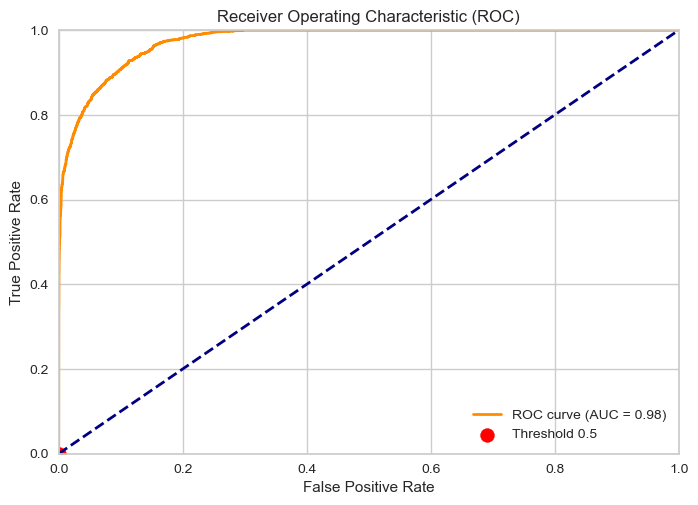

In [28]:
# 可视化
y_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[thresholds >= 0.5][0], tpr[thresholds >= 0.5][0], 
            color='red', s=100, label='Threshold 0.5')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.show()